# Contextual Bandit Reporting
Use this notebook to explore training logs, scenario outputs, and baseline comparisons.

In [30]:
import os
import sys
import pathlib

ROOT = pathlib.Path().resolve()
if not (ROOT / 'experiments').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from experiments.contextual_bandit_scenarios import (
    ScenarioConfig,
    ScenarioRunner,
    compute_baseline_reward_histories,
)
from agents.repricer_meta_actions import MetaActionLibrary
from agents.contextual_bandit_agent import ContextualBanditAgent, AgentConfig

RUN_DIR = pathlib.Path('../data/contextual_bandit_runs')
MODEL_DIR = pathlib.Path('../data/contextual_bandit_models')
SCENARIO_DIR = pathlib.Path('../data/contextual_bandit_scenarios')
for _dir in (RUN_DIR, MODEL_DIR, SCENARIO_DIR):
    _dir.mkdir(parents=True, exist_ok=True)
list(RUN_DIR.glob('run_*.json'))[:3]

[PosixPath('../data/contextual_bandit_runs/run_20251003T033956Z.json'),
 PosixPath('../data/contextual_bandit_runs/run_20251003T032247Z.json'),
 PosixPath('../data/contextual_bandit_runs/run_20251003T032711Z.json')]

## Training Run Diagnostics

In [23]:
def load_run(path):
    with open(path, 'r', encoding='utf-8') as handle:
        return json.load(handle)

run_files = sorted(RUN_DIR.glob('run_*.json'))
runs = [load_run(p) for p in run_files]
len(runs)

3

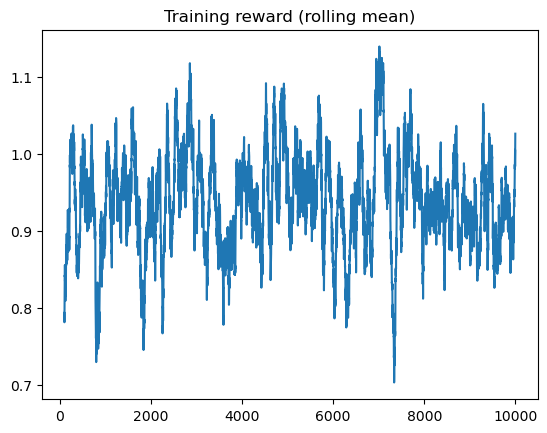

In [24]:
if runs:
    sample_run = runs[-1]
    df = pd.DataFrame(sample_run['logs'])
    df['avg_reward'] = df['rewards'].apply(np.mean)
    window = min(100, len(df))
    if window > 1:
        df['avg_reward'].rolling(window=window).mean().plot(title='Training reward (rolling mean)')
        plt.show()
    else:
        print('Not enough data to plot rolling reward.')
else:
    print('No training runs found. Train a bandit first.')

## Post-Training Scenarios

In [25]:
scenario_files = sorted(SCENARIO_DIR.glob('scenario_*.json'))
scenario_files[:3]

[]

In [ ]:
def load_scenario(path):
    with open(path, 'r', encoding='utf-8') as handle:
        return json.load(handle)

if scenario_files:
    scenario = load_scenario(scenario_files[-1])
    scenario['scenario']
else:
    print('No scenario outputs available yet.')

In [ ]:
def plot_network(stats: dict, kind: str = 'undercut'):
    matrix = np.array(stats[kind])
    n = matrix.shape[0]
    G = nx.DiGraph()
    for i in range(n):
        G.add_node(i)
    for i in range(n):
        for j in range(n):
            weight = matrix[i, j]
            if weight > 0:
                G.add_edge(i, j, weight=weight)
    pos = nx.spring_layout(G, seed=42)
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    nx.draw(G, pos, with_labels=True, node_color='lightblue',
            width=edge_weights, arrowsize=20)
    plt.title(f'{kind.title()} network (edge weight = count)')
    plt.show()

if scenario_files:
    latest_log = scenario['logs'][0]
    plot_network(latest_log['network_stats'], kind='undercut')
    plot_network(latest_log['network_stats'], kind='match')
    plot_network(latest_log['network_stats'], kind='above')
else:
    print('Create a scenario output to inspect networks.')

## Baseline Comparison

In [26]:
if runs:
    latest_run = runs[-1]
    summary = latest_run['summary']
    logs = latest_run['logs']
    model_path = summary['model_path']
    model_path = pathlib.Path(model_path)
    if not model_path.is_absolute():
        model_path = (ROOT / model_path).resolve()
    model_path = str(model_path)
    learner_type = summary['metadata']['learner']
    env_cfg = summary['config']['env']
    inner_periods = env_cfg['inner_periods']
    baseline_action_ids = [0, 1, 5, 9]
    baseline_data = compute_baseline_reward_histories(
        model_path=model_path,
        learner_type=learner_type,
        training_logs=logs,
        env_settings=env_cfg,
        inner_periods=inner_periods,
        action_ids=baseline_action_ids,
        max_samples=200,
        seller_index=0,
        seed=2024,
    )
    baseline_data['indices']
else:
    print('Train a bandit before computing baselines.')

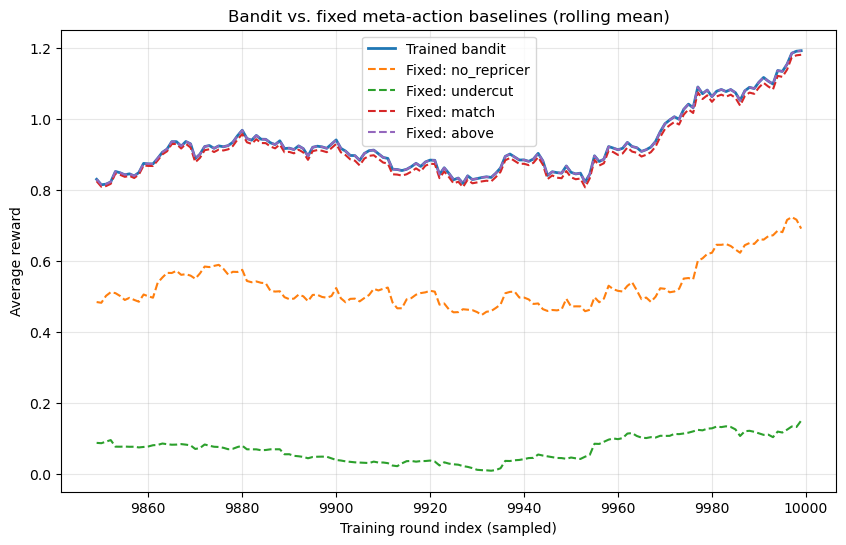

In [27]:
if runs:
    indices = baseline_data['indices']
    bandit_series = pd.Series(baseline_data['bandit_rewards'], index=indices)
    window = min(50, len(bandit_series)) or 1
    plt.figure(figsize=(10, 6))
    plt.plot(bandit_series.index, bandit_series.rolling(window).mean(), label='Trained bandit', linewidth=2)
    meta_lib = MetaActionLibrary()
    for aid, rewards in baseline_data['baseline_rewards'].items():
        series = pd.Series(rewards, index=indices)
        label = f'Fixed: {meta_lib.get_action(aid).name}'
        plt.plot(series.index, series.rolling(window).mean(), label=label, linestyle='--')
    plt.xlabel('Training round index (sampled)')
    plt.ylabel('Average reward')
    plt.title('Bandit vs. fixed meta-action baselines (rolling mean)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('No baseline data to plot.')

In [28]:
def collect_action_frequencies(model_path, learner_type, contexts, n_players=None):
    model_path = pathlib.Path(model_path)
    if not model_path.is_absolute():
        model_path = (ROOT / model_path).resolve()
    agent_cfg = AgentConfig(learner_type=learner_type)
    agent = ContextualBanditAgent.from_saved_model(str(model_path), agent_cfg, n_players=n_players)
    lib = MetaActionLibrary()
    counts = {a.action_id: 0 for a in lib.list_actions()}
    for ctx in contexts:
        actions, _, _ = agent.select_actions([ctx])
        counts[actions[0].action_id] += 1
    return counts


## Bandit Meta-Action Usage Across Contexts
The following plots sample contexts and record how often each meta action is selected.

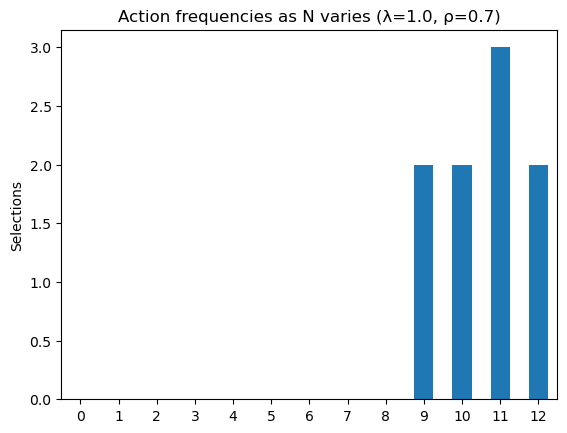

In [31]:
if runs:
    latest_run = runs[-1]
    summary = latest_run['summary']
    model_path = summary['model_path']
    learner_type = summary['metadata']['learner']
    contexts = [
        {'N': N, 'MC': 2.5, 'lambda': 1.0, 'rho': 0.7}
        for N in range(4, 21, 2)
    ]
    counts = collect_action_frequencies(model_path, learner_type, contexts)
    ax = pd.Series(counts).plot(kind='bar', rot=0, title='Action frequencies as N varies (λ=1.0, ρ=0.7)')
    ax.set_ylabel('Selections')
    plt.show()
else:
    print('Train a bandit before running action-frequency visualisations.')


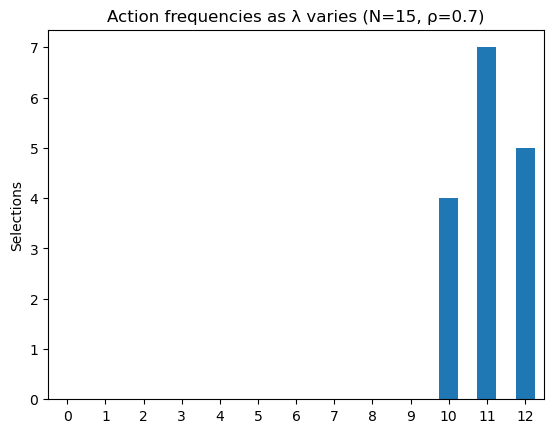

In [53]:
if runs:
    latest_run = runs[-1]
    summary = latest_run['summary']
    model_path = summary['model_path']
    learner_type = summary['metadata']['learner']
    contexts = [
        {'N': 15, 'MC': 2.5, 'lambda': lam, 'rho': 0.7}
        for lam in np.arange(0.5, 2.1, 0.1)
    ]
    counts = collect_action_frequencies(model_path, learner_type, contexts)
    ax = pd.Series(counts).plot(kind='bar', rot=0, title='Action frequencies as λ varies (N=15, ρ=0.7)')
    ax.set_ylabel('Selections')
    plt.show()
else:
    print('Train a bandit before running action-frequency visualisations.')


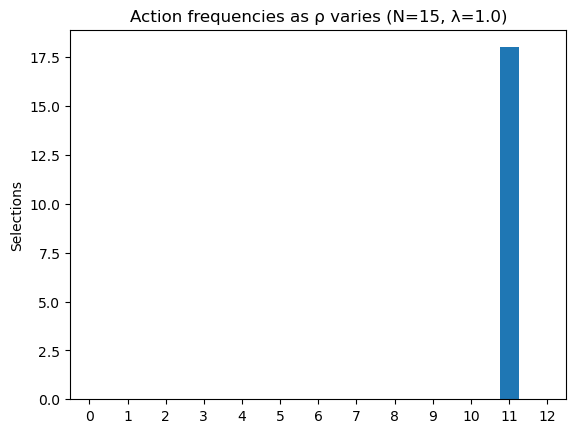

In [58]:
if runs:
    latest_run = runs[-1]
    summary = latest_run['summary']
    model_path = summary['model_path']
    learner_type = summary['metadata']['learner']
    contexts = [
        {'N': 15, 'MC': 4.5, 'lambda': 1.0, 'rho': rho}
        for rho in np.arange(0.1, 1.0, 0.05)
    ]
    counts = collect_action_frequencies(model_path, learner_type, contexts)
    ax = pd.Series(counts).plot(kind='bar', rot=0, title='Action frequencies as ρ varies (N=15, λ=1.0)')
    ax.set_ylabel('Selections')
    plt.show()
else:
    print('Train a bandit before running action-frequency visualisations.')


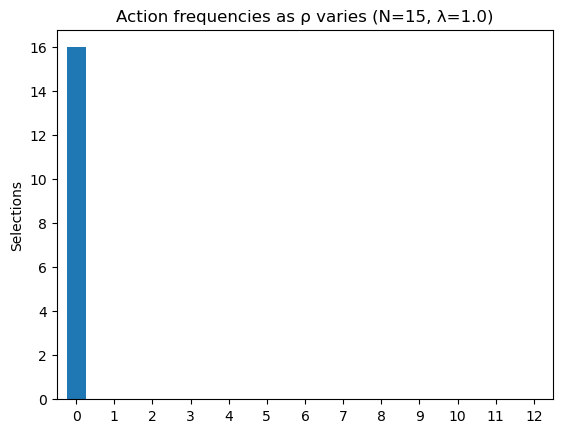

In [55]:
if runs:
    latest_run = runs[-1]
    summary = latest_run['summary']
    model_path = summary['model_path']
    learner_type = summary['metadata']['learner']
    contexts = [
        {'N': 15, 'MC': 8.5, 'lambda': 2.0, 'rho': rho}
        for rho in np.arange(0.05, 0.2, 0.01)
    ]
    counts = collect_action_frequencies(model_path, learner_type, contexts)
    ax = pd.Series(counts).plot(kind='bar', rot=0, title='Action frequencies as ρ varies (N=15, λ=1.0)')
    ax.set_ylabel('Selections')
    plt.show()
else:
    print('Train a bandit before running action-frequency visualisations.')
